In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [4]:
import pandas as pd
import numpy as np

import os
import sys

import librosa
import librosa.display
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

from IPython.display import Audio

import keras
from keras.callbacks import ReduceLROnPlateau
from keras.models import Sequential
from keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, Dropout, BatchNormalization, Activation
# from keras.utils import np_utils, to_categorical
from keras.utils import to_categorical
from keras.callbacks import ModelCheckpoint, History

import warnings
if not sys.warnoptions:
    warnings.simplefilter("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning) 

In [5]:
Ravdess = "/kaggle/input/ravdess-emotional-speech-audio/audio_speech_actors_01-24/"
Tess = "/kaggle/input/toronto-emotional-speech-set-tess/tess toronto emotional speech set data/TESS Toronto emotional speech set data/"

In [6]:
ravdess_directory_list = os.listdir(Ravdess)

file_emotion = []
file_path = []
for dir in ravdess_directory_list:
    actor = os.listdir(Ravdess + dir)
    for file in actor:
        part = file.split('.')[0]
        part = part.split('-')
        file_emotion.append(int(part[2]))
        file_path.append(Ravdess + dir + '/' + file)
        
emotion_df = pd.DataFrame(file_emotion, columns=['Emotions'])

path_df = pd.DataFrame(file_path, columns=['Path'])
Ravdess_df = pd.concat([emotion_df, path_df], axis=1)

Ravdess_df.Emotions.replace({1:'neutral', 2:'calm', 3:'happy', 4:'sad', 5:'angry', 6:'fear', 7:'disgust', 8:'surprise'}, inplace=True)
Ravdess_df.head()

,Emotions,Path
0,surprise,/kaggle/input/ravdess-emotional-speech-audio/a...
1,neutral,/kaggle/input/ravdess-emotional-speech-audio/a...
2,disgust,/kaggle/input/ravdess-emotional-speech-audio/a...
3,disgust,/kaggle/input/ravdess-emotional-speech-audio/a...
4,neutral,/kaggle/input/ravdess-emotional-speech-audio/a...


In [9]:
tess_directory_list = os.listdir(Tess)

file_emotion = []
file_path = []

for dir in tess_directory_list:
    directories = os.listdir(Tess + dir)
    for file in directories:
        part = file.split('.')[0]
        part = part.split('_')[2]
        if part=='ps':
            file_emotion.append('surprise')
        else:
            file_emotion.append(part)
        file_path.append(Tess + dir + '/' + file)
        
emotion_df = pd.DataFrame(file_emotion, columns=['Emotions'])

path_df = pd.DataFrame(file_path, columns=['Path'])
Tess_df = pd.concat([emotion_df, path_df], axis=1)
Tess_df.head()


,Emotions,Path
0,fear,/kaggle/input/toronto-emotional-speech-set-tes...
1,fear,/kaggle/input/toronto-emotional-speech-set-tes...
2,fear,/kaggle/input/toronto-emotional-speech-set-tes...
3,fear,/kaggle/input/toronto-emotional-speech-set-tes...
4,fear,/kaggle/input/toronto-emotional-speech-set-tes...


In [10]:
data_path = pd.concat([Ravdess_df,Tess_df], axis = 0)


data_path.to_csv("data_path.csv",index=False)
data_path.head()

,Emotions,Path
0,surprise,/kaggle/input/ravdess-emotional-speech-audio/a...
1,neutral,/kaggle/input/ravdess-emotional-speech-audio/a...
2,disgust,/kaggle/input/ravdess-emotional-speech-audio/a...
3,disgust,/kaggle/input/ravdess-emotional-speech-audio/a...
4,neutral,/kaggle/input/ravdess-emotional-speech-audio/a...


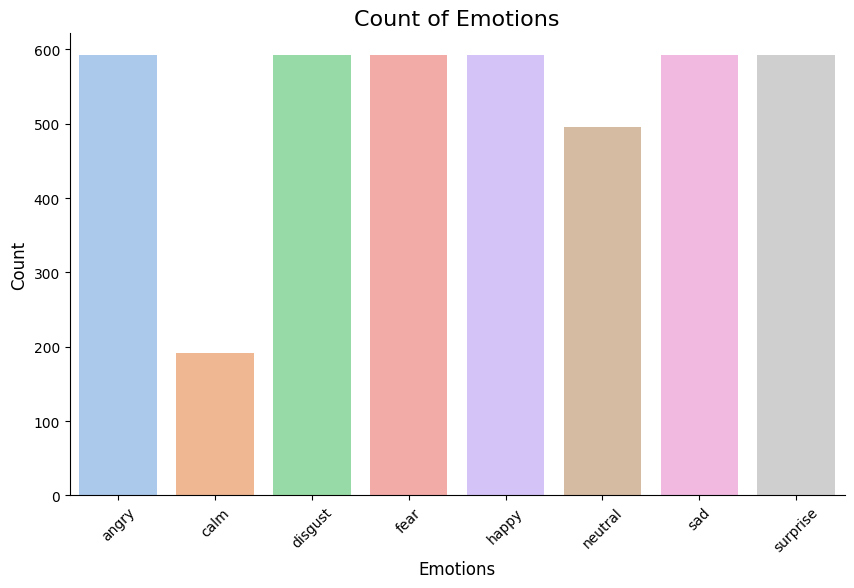

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Make sure that Emotions is treated as a categorical variable
data_path['Emotions'] = data_path['Emotions'].astype('category')

# Set the pastel color palette
pastel_colors = sns.color_palette("pastel", len(data_path.Emotions.cat.categories))

# Create the count plot
plt.figure(figsize=(10, 6))  # Optional: Set figure size
plt.title('Count of Emotions', size=16)
sns.countplot(x='Emotions', data=data_path, palette=pastel_colors)  # Use x='Emotions'
plt.ylabel('Count', size=12)
plt.xlabel('Emotions', size=12)
sns.despine(top=True, right=True, left=False, bottom=False)
plt.xticks(rotation=45)  # Optional: Rotate x-axis labels for better readability
plt.show()


In [13]:
def create_waveplot(data, sr, e):
    plt.figure(figsize=(10, 3))
    plt.title('Waveplot for audio with {} emotion'.format(e), size=15)
    librosa.display.waveplot(data, sr=sr)
    plt.show()

def create_spectrogram(data, sr, e):
    X = librosa.stft(data)
    Xdb = librosa.amplitude_to_db(abs(X))
    plt.figure(figsize=(12, 3))
    plt.title('Spectrogram for audio with {} emotion'.format(e), size=15)
    librosa.display.specshow(Xdb, sr=sr, x_axis='time', y_axis='hz')   
    plt.colorbar()

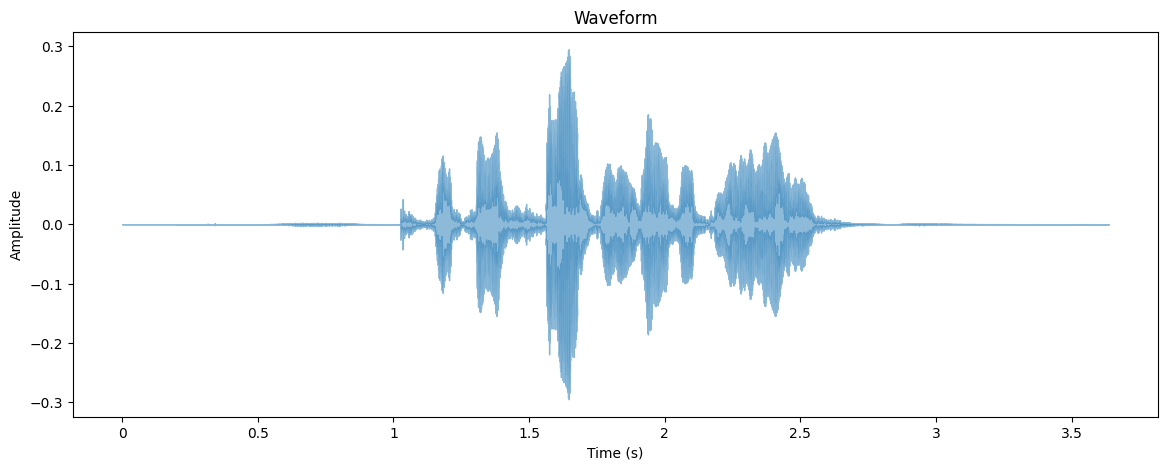

In [16]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

# Load your audio file
# audio_path = 'path_to_your_audio_file.wav'  # Update this with your audio file path
audio_path = np.array(data_path.Path[data_path.Emotions==emotion])[1]
y, sr = librosa.load(audio_path)

# Create a new figure
plt.figure(figsize=(14, 5))

# Plot the waveform
librosa.display.waveshow(y, sr=sr, alpha=0.5)  # use waveshow instead of waveplot in newer versions

plt.title('Waveform')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.show()


In [39]:
import numpy as np
import pandas as pd
import librosa

def noise(data):
    noise_amp = 0.035 * np.random.uniform() * np.amax(data)
    data = data + noise_amp * np.random.normal(size=data.shape[0])
    return data

# Changed the definition of the stretch function to remove 'self'
def stretch(data):
    # Rate is now used for the time_stretch function directly
    return librosa.effects.time_stretch(data, rate = 0.8)

def shift(data):
    shift_range = int(np.random.uniform(low=-5, high=5) * 1000)
    return np.roll(data, shift_range)

def pitch(data, sample_rate, pitch_factor=0.7):
    n_steps = int(pitch_factor * 12)  # Convert pitch factor to half-steps
    return librosa.effects.pitch_shift(data, sr=sample_rate, n_steps=n_steps)

def extract_features(data, sample_rate):
    result = np.array([])
    zcr = np.mean(librosa.feature.zero_crossing_rate(y=data).T, axis=0)
    result = np.hstack((result, zcr))

    stft = np.abs(librosa.stft(data))
    chroma_stft = np.mean(librosa.feature.chroma_stft(S=stft, sr=sample_rate).T, axis=0)
    result = np.hstack((result, chroma_stft))

    mfcc = np.mean(librosa.feature.mfcc(y=data, sr=sample_rate).T, axis=0)
    result = np.hstack((result, mfcc))

    rms = np.mean(librosa.feature.rms(y=data).T, axis=0)
    result = np.hstack((result, rms))

    mel = np.mean(librosa.feature.melspectrogram(y=data, sr=sample_rate).T, axis=0)
    result = np.hstack((result, mel))

    return result

def get_features(path):
    data, sample_rate = librosa.load(path, duration=2.5, offset=0.6)  # Load audio file

    res1 = extract_features(data, sample_rate)  # Extract features for original audio
    result = np.array(res1)

    noise_data = noise(data)  # Add noise
    res2 = extract_features(noise_data, sample_rate)  # Extract features for noisy audio
    result = np.vstack((result, res2))

    new_data = stretch(data)  # Time-stretch audio
    data_stretch_pitch = pitch(new_data, sample_rate)  # Shift pitch
    res3 = extract_features(data_stretch_pitch, sample_rate)  # Extract features for modified audio
    result = np.vstack((result, res3))

    return result

saved_features_filepath = "/kaggle/input/speech-emotion-recognition-output-checkpoint-1/features.csv"
if os.path.exists(saved_features_filepath):
    Features = pd.read_csv(saved_features_filepath)
else:
    X, Y = [], []
    for path, emotion in zip(data_path.Path, data_path.Emotions):
        feature = get_features(path)  # Call get_features with the audio path
        for ele in feature:
            X.append(ele)
            Y.append(emotion)

    Features = pd.DataFrame(X)
    Features['labels'] = Y
    Features.to_csv('features.csv', index=False)

print(Features.shape)


(12720, 163)


In [40]:
X = Features.drop('labels', axis=1).values
Y = Features['labels'].values


In [41]:
encoder = OneHotEncoder()
Y = encoder.fit_transform(np.array(Y).reshape(-1,1)).toarray()


In [42]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, random_state=0, shuffle=True, stratify=Y)
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((9540, 162), (9540, 8), (3180, 162), (3180, 8))

In [43]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((9540, 162), (9540, 8), (3180, 162), (3180, 8))

In [44]:
x_train = np.expand_dims(x_train, axis=2)
x_test = np.expand_dims(x_test, axis=2)
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((9540, 162, 1), (9540, 8), (3180, 162, 1), (3180, 8))

In [47]:
def plot_model_accuracy_loss(
    x_test: np.ndarray, y_test: np.ndarray,
    model: Sequential, history: History,
    *,
    epoch_number=50
):
    print("Accuracy of our model on test data : " , model.evaluate(x_test, y_test)[1]*100 , "%")

    epochs = [i for i in range(epoch_number)]
    fig , ax = plt.subplots(1,2)
    train_acc = history.history['accuracy']
    train_loss = history.history['loss']
    test_acc = history.history['val_accuracy']
    test_loss = history.history['val_loss']

    fig.set_size_inches(20,6)
    ax[0].plot(epochs , train_loss , label = 'Training Loss')
    ax[0].plot(epochs , test_loss , label = 'Testing Loss')
    ax[0].set_title('Training & Testing Loss')
    ax[0].legend()
    ax[0].set_xlabel("Epochs")

    ax[1].plot(epochs , train_acc , label = 'Training Accuracy')
    ax[1].plot(epochs , test_acc , label = 'Testing Accuracy')
    ax[1].set_title('Training & Testing Accuracy')
    ax[1].legend()
    ax[1].set_xlabel("Epochs")
    plt.show()

In [48]:
from keras.optimizers import Adam

In [49]:
cnn_model=Sequential()
cnn_model.add(Conv1D(256, kernel_size=5, strides=1, padding='same', activation='relu', input_shape=(x_train.shape[1], 1)))
cnn_model.add(MaxPooling1D(pool_size=5, strides = 2, padding = 'same'))

cnn_model.add(Conv1D(256, kernel_size=5, strides=1, padding='same', activation='relu'))
cnn_model.add(MaxPooling1D(pool_size=5, strides = 2, padding = 'same'))

cnn_model.add(Conv1D(128, kernel_size=5, strides=1, padding='same', activation='relu'))
cnn_model.add(MaxPooling1D(pool_size=5, strides = 2, padding = 'same'))
cnn_model.add(Dropout(0.2))

cnn_model.add(Conv1D(64, kernel_size=5, strides=1, padding='same', activation='relu'))
cnn_model.add(MaxPooling1D(pool_size=5, strides = 2, padding = 'same'))

cnn_model.add(Flatten())
cnn_model.add(Dense(units=32, activation='relu'))
cnn_model.add(Dropout(0.3))

cnn_model.add(Dense(units=8, activation='softmax'))
cnn_model.compile(optimizer = 'adam' , loss = 'categorical_crossentropy' , metrics = ['accuracy'])

cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 162, 256)       │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 81, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 81, 256)        │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 41, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 41, 128)        │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 21, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 21, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 21, 64)         │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 11, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 704)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        22,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 557,288 (2.13 MB)

 Trainable params: 557,288 (2.13 MB)

 Non-trainable params: 0 (0.00 B)

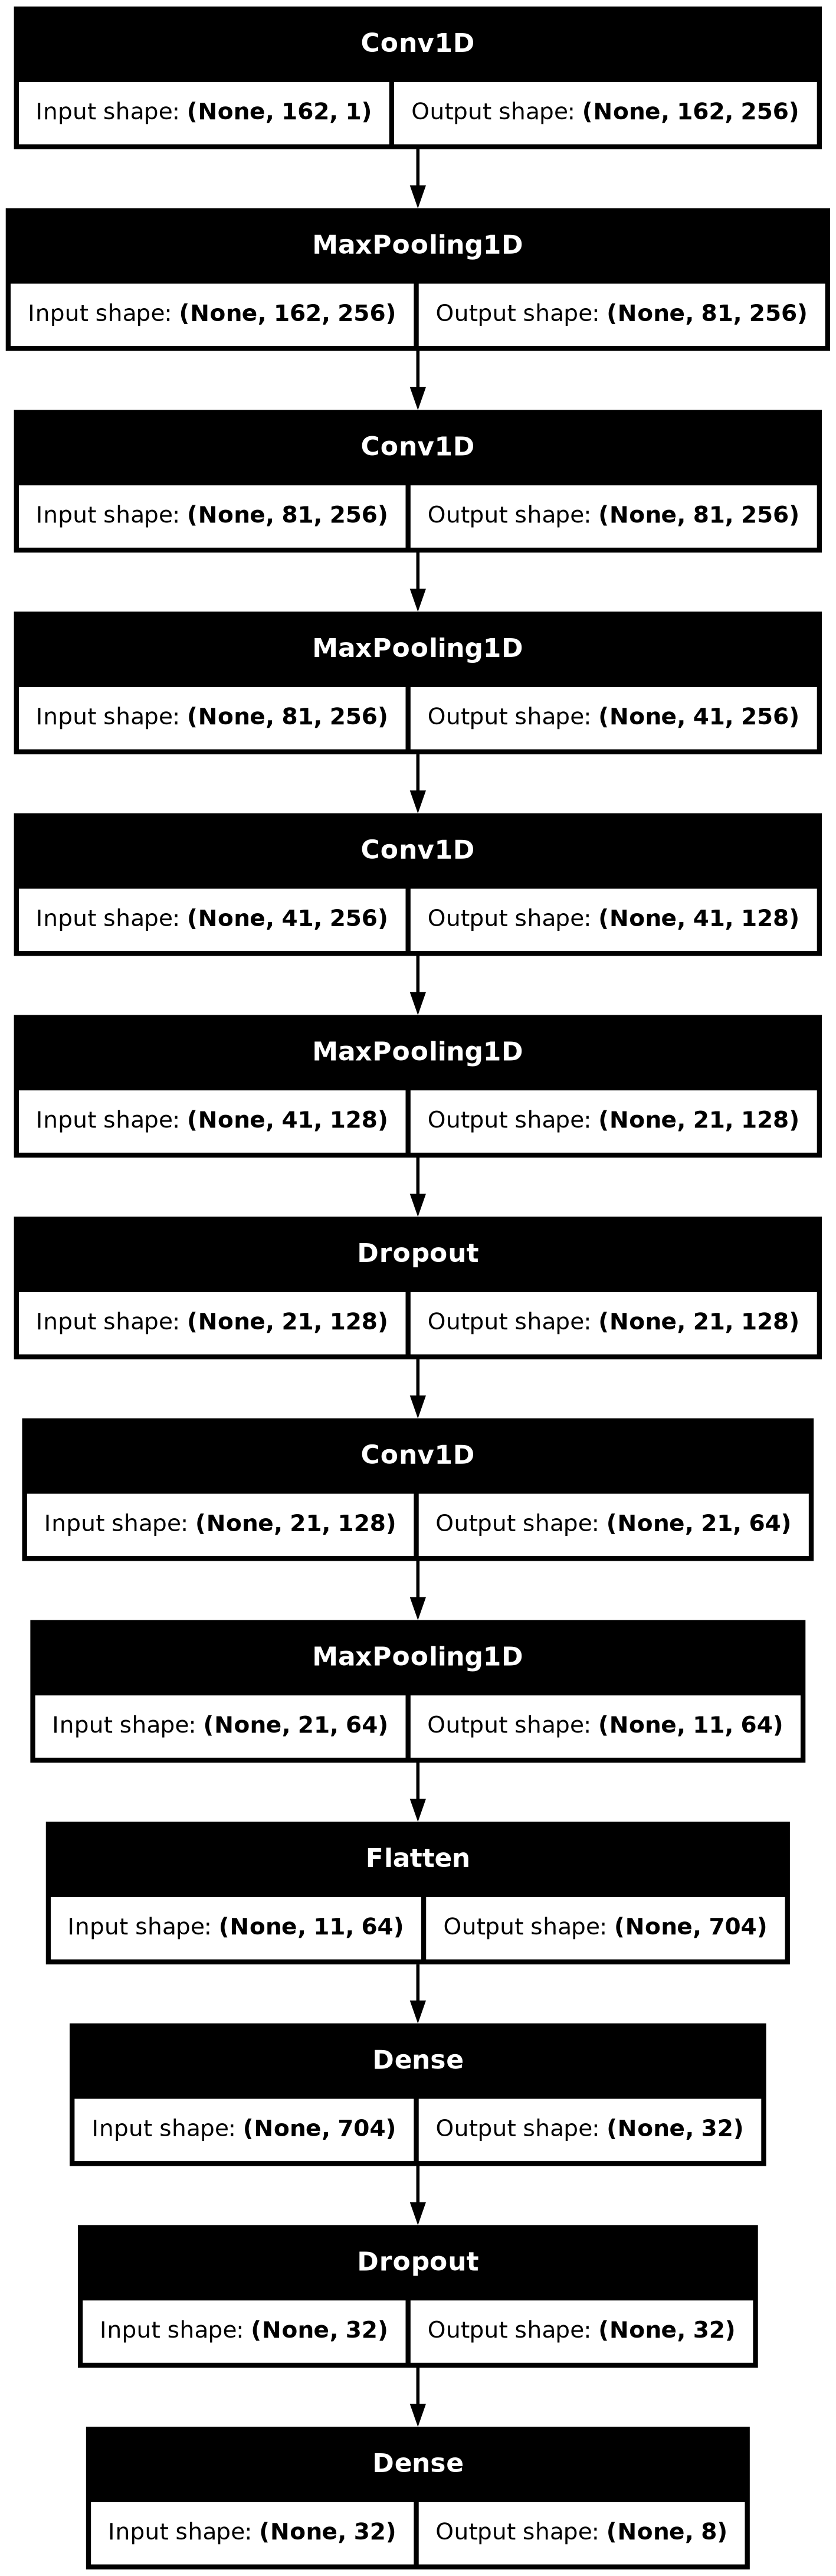

In [51]:
from keras.utils import plot_model  # Importing plot_model

plot_model(cnn_model, to_file='cnn_model_architecture.png', show_shapes=True)

In [52]:
rlrp = ReduceLROnPlateau(monitor='loss', factor=0.4, verbose=0, patience=2, min_lr=0.0000001)

# Tracking training time
start_time = time.time()
history = cnn_model.fit(x_train, y_train, batch_size=64, epochs=100, validation_data=(x_test, y_test), callbacks=[rlrp])
end_time = time.time()

Epoch 1/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 38s 233ms/step - accuracy: 0.2551 - loss: 1.8909 - val_accuracy: 0.5072 - val_loss: 1.3967 - learning_rate: 0.0010
Epoch 2/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 40s 229ms/step - accuracy: 0.4871 - loss: 1.3739 - val_accuracy: 0.6110 - val_loss: 1.0861 - learning_rate: 0.0010
Epoch 3/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 35s 235ms/step - accuracy: 0.5553 - loss: 1.1804 - val_accuracy: 0.6881 - val_loss: 0.9099 - learning_rate: 0.0010
Epoch 4/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 40s 227ms/step - accuracy: 0.6168 - loss: 1.0357 - val_accuracy: 0.7091 - val_loss: 0.8384 - learning_rate: 0.0010
Epoch 5/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 34s 228ms/step - accuracy: 0.6690 - loss: 0.9267 - val_accuracy: 0.7022 - val_loss: 0.8210 - learning_rate: 0.0010
Epoch 6/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 41s 228ms/step - accuracy: 0.6788 - loss: 0.8580 - val_accuracy: 0.7252 - val_loss: 0.7628 - learning_rate: 0.0010
Epoch 7/100
150/150 ━━━━━━━━━━━━━━━━━━━━ 34s 225ms/step - accura

100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.8363 - loss: 0.5714
Accuracy of our model on test data :  84.3710720539093 %


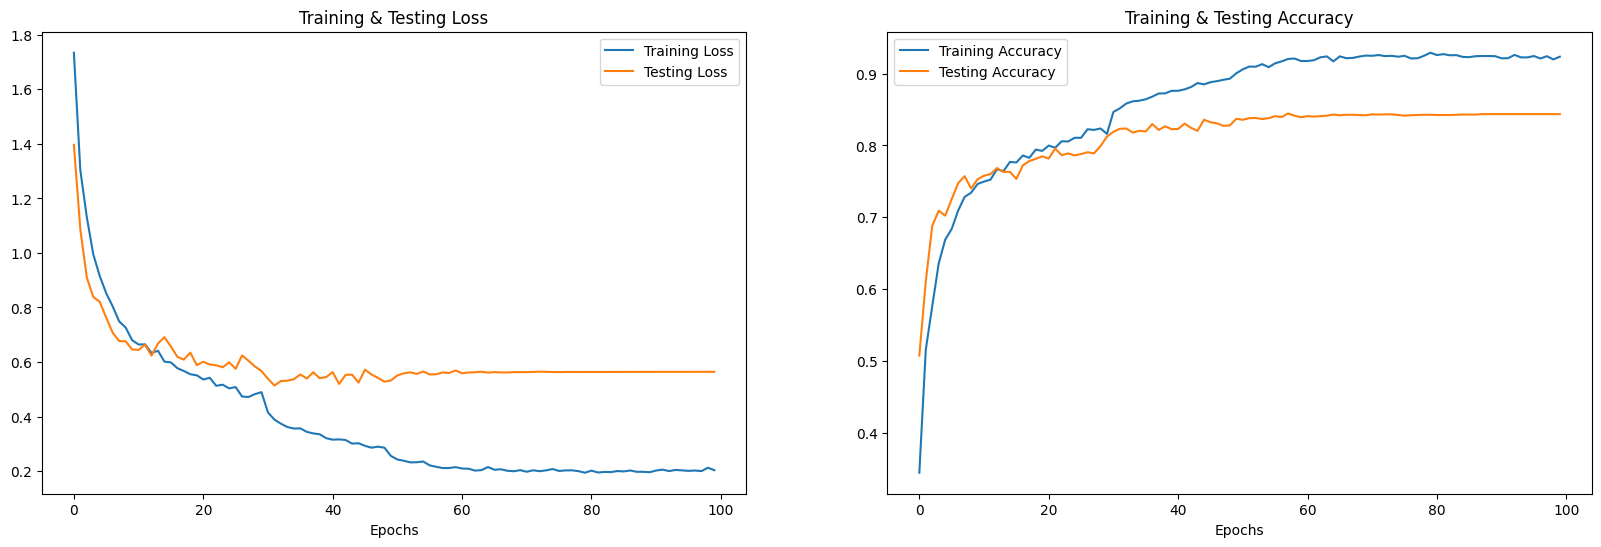

In [53]:
plot_model_accuracy_loss(
    x_test=x_test, y_test=y_test, 
    model=cnn_model, history=history,
    epoch_number=100,
)

In [56]:
pred_test = cnn_model.predict(x_test)
y_pred = encoder.inverse_transform(pred_test)
y_test = encoder.inverse_transform(y_test)

100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step


In [57]:
df = pd.DataFrame(columns=['Predicted Labels', 'Actual Labels'])
df['Predicted Labels'] = y_pred.flatten()
df['Actual Labels'] = y_test.flatten()
df.head(10)

,Predicted Labels,Actual Labels
0,angry,angry
1,fear,fear
2,happy,happy
3,angry,angry
4,happy,angry
5,disgust,angry
6,fear,sad
7,angry,angry
8,disgust,disgust
9,sad,sad


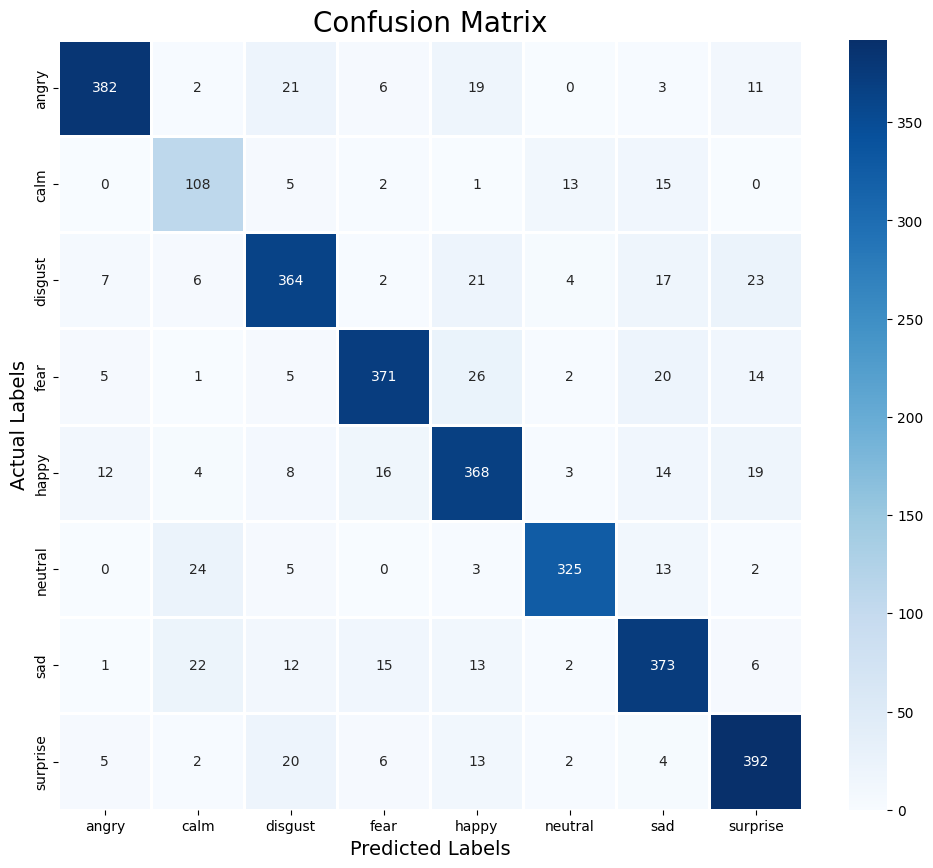

In [58]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize = (12, 10))
cm = pd.DataFrame(cm , index = [i for i in encoder.categories_] , columns = [i for i in encoder.categories_])
sns.heatmap(cm, linecolor='white', cmap='Blues', linewidth=1, annot=True, fmt='')
plt.title('Confusion Matrix', size=20)
plt.xlabel('Predicted Labels', size=14)
plt.ylabel('Actual Labels', size=14)
plt.show()

In [59]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       angry       0.93      0.86      0.89       444
        calm       0.64      0.75      0.69       144
     disgust       0.83      0.82      0.82       444
        fear       0.89      0.84      0.86       444
       happy       0.79      0.83      0.81       444
     neutral       0.93      0.87      0.90       372
         sad       0.81      0.84      0.83       444
    surprise       0.84      0.88      0.86       444

    accuracy                           0.84      3180
   macro avg       0.83      0.84      0.83      3180
weighted avg       0.85      0.84      0.84      3180



In [61]:
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

f1 = f1_score(y_test, y_pred, average='weighted')
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
accuracy = accuracy_score(y_test, y_pred)

# Print the metrics
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Accuracy: {accuracy:.4f}")

F1 Score: 0.8449
Precision: 0.8475
Recall: 0.8437
Accuracy: 0.8437
